In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


1.   
**Load the CSV file into pandas. What are the dimensions of the dataset**   
(166,10)

**Display the first 5 rows.
Report the number of rows and columns.**   
166 Rows, 10 Columns

In [2]:
import pandas as pd


In [3]:
raw_data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Assignment One/SLCM_Basic_Needs_Class_Practice.csv')

In [4]:
raw_data.head()

,Housing_Status,Monthly_Housing_Cost,Moves_Last_3_Years,Utility_Disconnection_Risk,Monthly_LGE_Bill,Monthly_Water_Bill,Eviction_Record,Transportation_Need_Score,Has_Car,Bus_Use
0,Renter - past due rent,1200.0,0,Yes,225.0,200.0,No,1,Yes,Never
1,Renter - past due rent,0.0,1,No,217.0,144.0,No,2,Yes,Never
2,Staying with friends or family,800.0,4,No,100.0,100.0,No,5,Yes,Sometimes
3,Homeless,0.0,2,No,0.0,0.0,Yes,0,Yes,Never
4,Homeless,0.0,3,No,0.0,0.0,Yes,3,Yes,Rarely


In [5]:
raw_data.shape

(166, 10)

166 rows, 10 columns

2.  
**What variables are available?**  
'Housing_Status', 'Monthly_Housing_Cost', 'Moves_Last_3_Years',
       'Utility_Disconnection_Risk', 'Monthly_LGE_Bill', 'Monthly_Water_Bill',
       'Eviction_Record', 'Transportation_Need_Score', 'Has_Car', 'Bus_Use'

**For each variable, write one short sentence describing what you think it represents.**

Housing_Status: Whether they have a home or not.  
Monthly_Housing_Cost: How much their rent is.  
Moves_Last_3_Years: How many times they've moved in the last 3 years.  
Utility_Disconnection_Risk: Classification for how at risk a person is of having utilities shut off.  
Monthly_LGE_Bill: How much their gas and electric cost monthly.  
Monthly_Water_Bill: How much their water costs monthly.  
Eviction_Record: Whether or not they've been evicted before.  
Transportation_Need_Score: number scale for how much they need transport help.  
Has_Car: if they have a car or not.  
Bus_Use: how much they use the bus.  


In [6]:
raw_data.columns

Index(['Housing_Status', 'Monthly_Housing_Cost', 'Moves_Last_3_Years',
       'Utility_Disconnection_Risk', 'Monthly_LGE_Bill', 'Monthly_Water_Bill',
       'Eviction_Record', 'Transportation_Need_Score', 'Has_Car', 'Bus_Use'],
      dtype='object')

3.  
**What data types did pandas assign to the variables?**


In [7]:
raw_data.dtypes

,0
Housing_Status,object
Monthly_Housing_Cost,float64
Moves_Last_3_Years,object
Utility_Disconnection_Risk,object
Monthly_LGE_Bill,float64
Monthly_Water_Bill,float64
Eviction_Record,object
Transportation_Need_Score,int64
Has_Car,object
Bus_Use,object


**Which columns are numeric?**  


In [8]:
#output the columns that are numeric from raw_data
raw_data.select_dtypes(include="number")

,Monthly_Housing_Cost,Monthly_LGE_Bill,Monthly_Water_Bill,Transportation_Need_Score
0,1200.0,225.0,200.0,1
1,0.0,217.0,144.0,2
2,800.0,100.0,100.0,5
3,0.0,0.0,0.0,0
4,0.0,0.0,0.0,3
...,...,...,...,...
161,1500.0,150.0,60.0,3
162,0.0,30.0,0.0,0
163,18.0,0.0,0.0,1
164,710.0,0.0,0.0,3


**Which columns are categorical/object?**


In [9]:
raw_data.select_dtypes(include="object")

,Housing_Status,Moves_Last_3_Years,Utility_Disconnection_Risk,Eviction_Record,Has_Car,Bus_Use
0,Renter - past due rent,0,Yes,No,Yes,Never
1,Renter - past due rent,1,No,No,Yes,Never
2,Staying with friends or family,4,No,No,Yes,Sometimes
3,Homeless,2,No,Yes,Yes,Never
4,Homeless,3,No,Yes,Yes,Rarely
...,...,...,...,...,...,...
161,Renter - no rent past due,3,No,Yes,Yes,Sometimes
162,Renter - no rent past due,2,No,No,Yes,Never
163,Renter - no rent past due,0,No,No,No,Never
164,Renter - past due rent,1,No,No,Yes,Rarely


**Does any column have a data type that makes you want to inspect it more closely? Explain.**  

Yes, Moves_Last_3_Years being an object instead of int64 like transport_need seems like a mistake.

4.  
**What values occur in each categorical variable?**

In [10]:
# use value_counts() for Housing_Status, Utility_Disconnection_Risk, Eviction_Record, Has_Car, Bus_Use, and Moves_Last_3_Years.
raw_data['Housing_Status'].value_counts().sort_values(ascending=False)


,count
Housing_Status,
Renter - no rent past due,68
Renter - past due rent,51
Homeless,19
Staying at extended stay hotel or short-term housing,15
Staying with friends or family,12
Own home - mortgage past due,1


In [11]:
raw_data['Utility_Disconnection_Risk'].value_counts().sort_values(ascending=False)


,count
Utility_Disconnection_Risk,
No,116
Yes,40
Maybe,10


In [12]:
raw_data['Eviction_Record'].value_counts().sort_values(ascending=False)

,count
Eviction_Record,
No,114
Yes,42
Not sure,10


In [13]:
raw_data['Has_Car'].value_counts().sort_values(ascending=False)

,count
Has_Car,
Yes,87
No,79


In [14]:
raw_data['Bus_Use'].value_counts().sort_values(ascending=False)

,count
Bus_Use,
Never,66
Often,47
Sometimes,35
Rarely,18


**Do you notice any values that may need clarification or cleaning?**

The maybes and not sures on evictions and utility_disconnection_risk, they make up 20/166 data points though so throwing away ~12% of data rows does not seem a viable option

5.  
**Are there missing values or duplicate rows?**

In [15]:
raw_data.isnull().sum()

,0
Housing_Status,0
Monthly_Housing_Cost,0
Moves_Last_3_Years,0
Utility_Disconnection_Risk,0
Monthly_LGE_Bill,0
Monthly_Water_Bill,0
Eviction_Record,0
Transportation_Need_Score,0
Has_Car,0
Bus_Use,0


In [16]:
raw_data.duplicated().sum()

np.int64(1)

No null values, one duplicate row so the dupe row will be dropped later

6.  
**What do the numeric variables look like?**

In [17]:
# Use describe() for Monthly_Housing_Cost, Monthly_LGE_Bill, Monthly_Water_Bill, and Transportation_Need_Score
raw_data['Monthly_Housing_Cost'].describe()

,Monthly_Housing_Cost
count,166.000000
mean,625.209181
std,560.109409
min,0.000000
25%,0.010000
50%,550.000000
75%,1100.000000
max,2000.000000


In [18]:
raw_data['Monthly_LGE_Bill'].describe()

,Monthly_LGE_Bill
count,166.000000
mean,420.003320
std,3587.214867
min,0.000000
25%,0.010000
50%,120.000000
75%,200.000000
max,46247.000000


In [19]:
raw_data['Monthly_Water_Bill'].describe()

,Monthly_Water_Bill
count,166.000000
mean,42.167815
std,99.524462
min,0.000000
25%,0.000000
50%,0.010000
75%,60.000000
max,1000.000000


In [20]:
raw_data['Transportation_Need_Score'].describe()

,Transportation_Need_Score
count,166.000000
mean,2.433735
std,1.796918
min,0.000000
25%,1.000000
50%,3.000000
75%,4.000000
max,5.000000


**Which values look unusual or deserve a closer look?**

- The max on Monthly_LGE_Bill is absurdly high skewing the mean and std
- 50% of people have essentially no water bill


7.  
**Investigate zero values**

In [21]:
# Count how many records have Monthly_Housing_Cost = 0.
raw_data[raw_data['Monthly_Housing_Cost'] == 0].shape

(31, 10)

In [22]:
# Count how many records have Monthly_LGE_Bill = 0
raw_data[raw_data['Monthly_LGE_Bill'] == 0].shape

(36, 10)

In [23]:
# water bill
raw_data[raw_data['Monthly_Water_Bill'] == 0].shape

(69, 10)

In [24]:
# Look at Housing_Status for records with Monthly_Housing_Cost = 0.
raw_data[raw_data['Monthly_Housing_Cost'] == 0]['Housing_Status'].value_counts()

,count
Housing_Status,
Renter - no rent past due,14
Homeless,13
Staying with friends or family,2
Renter - past due rent,1
Staying at extended stay hotel or short-term housing,1


**Does a zero always appear to mean "bad data"? Explain what else zero could reasonably mean in this dataset.**

No a zero does not always mean bad data. Homeless or staying with friends/family for example it makes sense they aren't paying any rent. Renter - no rent past due however is likely bad data as they should be paying rent.

8.  
**Investigate Moves_Last_3_Years**
**Display all unique values and their counts.**

In [25]:
raw_data['Moves_Last_3_Years'].value_counts()

,count
Moves_Last_3_Years,
1,43
2,40
0,34
3,20
More than 5,15
4,10
5,4


**Can the values be used directly as numbers?**  
**If not, explain how you would clean or recode this variable for future analysis.**

No because of the "More than 5" value, otherwise it would've been able to be int64 dtype.  
To fix this for future analysis I would turn "More than 5" into "6" and then convert the dtype to int64.   
It would not be a perfect solution however I feel it would serve to approximate values higher than 5 close enough, as each value above 5 would only have a few data points each not allowing them to have much significance anyway.

9.  
**Make a cleaned working copy of the dataset.**

In [26]:
clean = raw_data.copy()

**Make 2 changes based on the observations above**

Change 1: Drop the duplicated row.  
This is done beceause we dont want duplicated data.

In [27]:
clean.drop_duplicates(inplace=True)

In [28]:
clean.duplicated().sum()

np.int64(0)

Change 2: Drop rows that have Monthly_Housing_Cost = 0 while Housing_Status = "Renter - no rent past due"  
This is done because a renter should always have a monthly housing cost, if they have none then this is bad data.

In [29]:
# Drop rows that have Monthly_Housing_Cost = 0 while Housing_Status = "Renter - no rent past due"
clean.drop(clean[(clean['Monthly_Housing_Cost'] == 0) & (clean['Housing_Status'] == "Renter - no rent past due")].index, inplace=True)

In [30]:
# verify it worked
clean[clean['Monthly_Housing_Cost'] == 0]['Housing_Status'].value_counts()

,count
Housing_Status,
Homeless,12
Staying with friends or family,2
Renter - past due rent,1
Staying at extended stay hotel or short-term housing,1


10.  
**Create a frequency table for Housing_Status**

In [31]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [32]:
# Create a frequency table for Housing_Status.
clean['Housing_Status'].value_counts()

,count
Housing_Status,
Renter - no rent past due,54
Renter - past due rent,51
Homeless,18
Staying at extended stay hotel or short-term housing,15
Staying with friends or family,12
Own home - mortgage past due,1


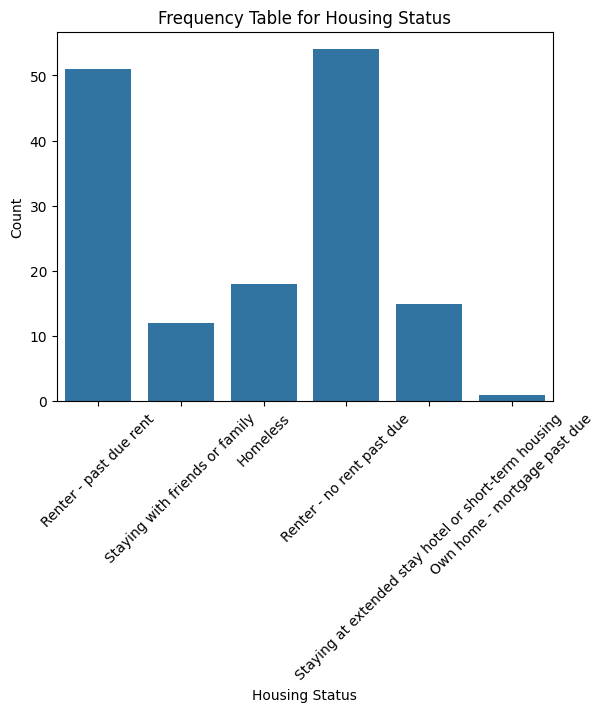

In [33]:
sns.countplot(x='Housing_Status', data=clean)
plt.xticks(rotation=45)
plt.xlabel('Housing Status')
plt.ylabel('Count')
plt.title('Frequency Table for Housing Status')
plt.show()

**Which housing status is most common? What do you notice about the overall distribution?**

"Renter - no rent past due" is the most common.  
Overall, the distribution is heavily skewed towards renters, with essentially no one owning a home or staying at families or friends places.

11.  
**Compare Monthly_Housing_Cost across Housing_Status.**

In [34]:
# Compare Monthly_Housing_Cost across Housing_Status. no graph yet, no sns yet
clean.groupby('Housing_Status')['Monthly_Housing_Cost'].mean()

,Monthly_Housing_Cost
Housing_Status,
Homeless,50.057778
Own home - mortgage past due,1376.020000
Renter - no rent past due,750.622611
Renter - past due rent,917.470784
Staying at extended stay hotel or short-term housing,740.867333
Staying with friends or family,255.835250


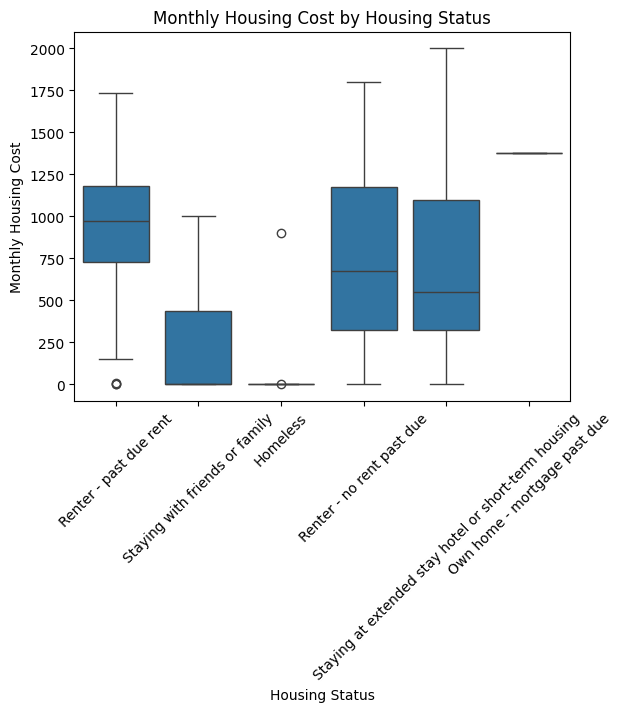

In [35]:
# create an appropriate visualization
sns.boxplot(x='Housing_Status', y='Monthly_Housing_Cost', data=clean)
plt.xticks(rotation=45)
plt.xlabel('Housing Status')
plt.ylabel('Monthly Housing Cost')
plt.title('Monthly Housing Cost by Housing Status')
plt.show()

**What pattern do you notice?**  
**Be careful when interpreting zero housing cost. Explain why**

The renters whose rent is past due on average have ~\$250 more expensive rent than those whose rent is not past due.  
The homeless values are essentially all at 0 which makes sense except for an outlier at ~\$900 which does not make sense. This is likely a piece of bad data missed in the initial sweep.

12.  
**Is utility disconnection risk associated with a different LG&E bill pattern?**  
**Compare Monthly_LGE_Bill for people with different Utility_Disconnection_Risk values**

In [36]:
# Compare Monthly_LGE_Bill for people with different Utility_Disconnection_Risk values
clean.groupby('Utility_Disconnection_Risk')['Monthly_LGE_Bill'].mean()

,Monthly_LGE_Bill
Utility_Disconnection_Risk,
Maybe,205.700000
No,96.395534
Yes,1535.056111


**Create an appropriate visualization.**

<Axes: xlabel='Monthly_LGE_Bill', ylabel='Count'>

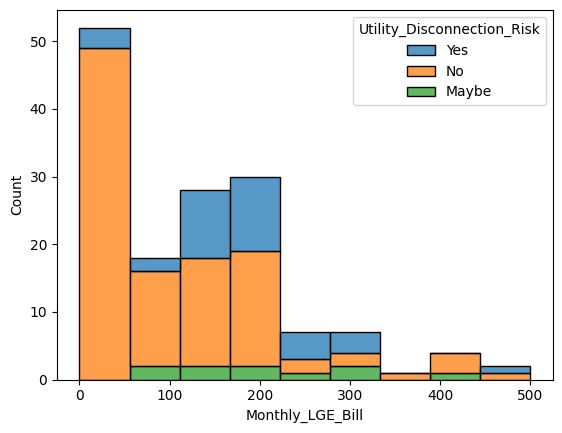

In [39]:
# Create an appropriate visualization. histogram with disconnection risk as hue for monthly prices less than 2000 only
sns.histplot(data=clean[clean['Monthly_LGE_Bill'] < 2000], x='Monthly_LGE_Bill', hue='Utility_Disconnection_Risk', multiple='stack')


**Describe what you observe. Do not claim that one variable causes the other.**

People with high monthly lge bills, \$1000+, are on average at higher risk than those with <\$100 monthly bills. This alone does not show not necessarily show causation though, just a trend in the data.
  
It also seems like an abnormally high monthly bill was missed during data cleaning, inflating some values.

13.  
**What does transportation need look like for people with and without a car?**  
**Compare Transportation_Need_Score by Has_Car.**  
**Use summary statistics and a visualization.**

In [40]:
clean.groupby('Has_Car')['Transportation_Need_Score'].mean()

,Transportation_Need_Score
Has_Car,
No,3.276316
Yes,1.733333


Text(0.5, 1.0, 'Transportation Need Score by Has Car')

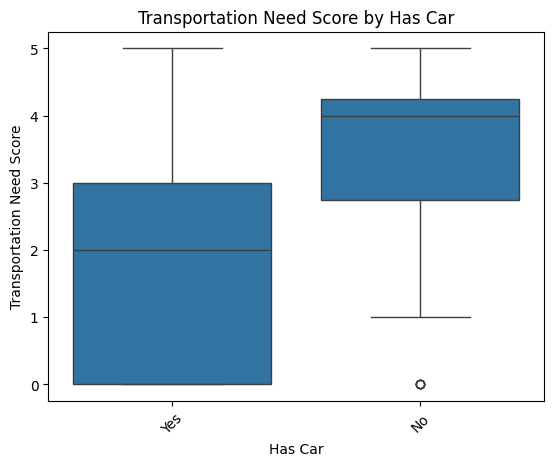

In [41]:
sns.boxplot(x='Has_Car', y='Transportation_Need_Score', data=clean)
plt.xticks(rotation=45)
plt.xlabel('Has Car')
plt.ylabel('Transportation Need Score')
plt.title('Transportation Need Score by Has Car')

**Does car ownership appear related to transportation need in this dataset? Explain using evidence.**

Yes they do appear related, people that do on have a car almost always have a higher transport need score than people with a car.  
Logically, this also makes sense as if someone does not have a car they almost always have less travel options than those with a car.  

The mean score of those without a car vs those with a car is a difference of ~2 points, on a 5 point scale.

14.  
**How is bus use distributed?**  
**Create a frequency table and visualization for Bus_Use.**

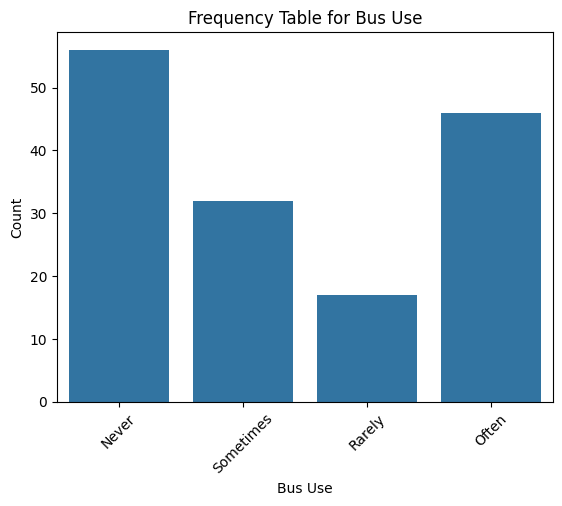

In [42]:
# Create a frequency table and visualization for Bus_Use.
sns.countplot(x='Bus_Use', data=clean)
plt.xticks(rotation=45)
plt.xlabel('Bus Use')
plt.ylabel('Count')
plt.title('Frequency Table for Bus Use')
plt.show()

**What is the most common bus-use category?**

The most common bus-use category is never.

**What additional variable would you compare with Bus_Use if you wanted to understand transportation needs better? Why?**

I would compare bus_use with has_car.

15.  
**What is your question?**  
Is Bus_Use correlated with Has_Car  
**Why did you choose this question? What made you curious about it, and why might it be useful to understand?**  
I choose this question because the previous question already hinted at a possible correlation, and intuitively it would make sense if there was one, so it makes sense to verify that this intuition is correct.  
**Which variables will you use to investigate it?**  
Bus_Use and Has_Car

16.  
**What does the data tell you?**

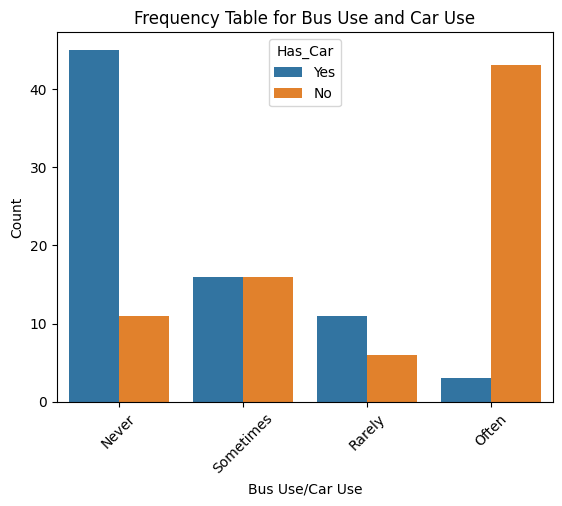

In [46]:
# create a histogram for has_car with a hue of bus_use
sns.countplot(x='Bus_Use', data=clean, hue='Has_Car')
plt.xticks(rotation=45)
plt.xlabel('Bus Use/Car Use')
plt.ylabel('Count')
plt.title('Frequency Table for Bus Use and Car Use')
plt.show()

**Explain what the result suggests in plain language.**

Initially this appears to show strong inverse correlations between the two in the "Never" and "Often" categories while "sometimes" and "rarely" are more closely correlated

17.  
**What is your overall finding?**  
Overall it appears that when someone never uses the bus they usually have a car, and equivalently when someone often rides the bus they almost never own a car.  
For those that sometimes or rarely ride the bus, car ownership or not is split roughly equally.  
  
One limitation is that we are using only 166 data points, and it is hard to confidentely declare a strong correlation with so few pieces of data without further analysis in other larger datasets that track similar information.